In [7]:
import numpy as np
import matplotlib.pyplot as plt
import warnings

D = 0.01
r = 1.0
L = 1.0

Nx = 201
x = np.linspace(0.0, L, Nx)
dx = x[1] - x[0]

def u0(x):
    return np.exp(-100.0*(x-0.5)**2)

u_init = u0(x)

def dt_limit_diffusion(D, dx):
    return dx**2/(2.0*D)

print(f"Nx={Nx}, dx={dx:.6f}, FTCS diffusion limit dt <= {dt_limit_diffusion(D,dx):.6g}")

Nx=201, dx=0.005000, FTCS diffusion limit dt <= 0.00125


In [8]:
def laplacian_neumann(u, dx):
    Lu = np.empty_like(u)
    Lu[1:-1] = (u[2:] - 2*u[1:-1] + u[:-2]) / dx**2
    Lu[0]    = 2*(u[1]  - u[0])  / dx**2
    Lu[-1]   = 2*(u[-2] - u[-1]) / dx**2
    return Lu

In [9]:
def solve_ftcs(u0_vec, dt, t_end, clamp01=False, allow_unstable=False):
    limit = dt_limit_diffusion(D, dx)
    if not allow_unstable and dt > limit + 1e-15:
        raise ValueError(f"FTCS unstable: dt={dt:.6g} > dt_limit={limit:.6g}. "
                         f"Use smaller dt or an implicit/IMEX scheme.")

    u = u0_vec.copy()
    steps = int(np.ceil(t_end/dt))
    times = np.zeros(steps+1)
    history = np.zeros((steps+1, u.size))
    history[0] = u
    t = 0.0
    for n in range(steps):
        Lu = laplacian_neumann(u, dx)
        u = u + dt*(D*Lu + r*u*(1.0 - u))
        if clamp01:
            u = np.clip(u, 0.0, 1.0)
        if not np.all(np.isfinite(u)):
            raise FloatingPointError(f"Non-finite values encountered at step {n+1}, t~{(n+1)*dt:.6g}. "
                                     f"Likely due to instability; reduce dt or use IMEX.")
        t = min((n+1)*dt, t_end)
        times[n+1] = t
        history[n+1] = u
    return times, history

In [10]:
def build_neumann_tridiagonals(N, dx):
    invdx2 = 1.0/dx**2
    a = np.zeros(N)  
    b = np.zeros(N) 
    c = np.zeros(N)  
    b[0] = -2*invdx2;  c[0] =  2*invdx2
    a[1:-1] = 1*invdx2; b[1:-1] = -2*invdx2; c[1:-1] = 1*invdx2
    a[-1] =  2*invdx2;  b[-1] = -2*invdx2;  c[-1] = 0.0
    return a, b, c

def thomas_factor(a, b, c):
    N = len(b); l = np.zeros(N); u = np.zeros(N)
    u[0] = b[0]
    for i in range(1, N):
        l[i] = a[i] / u[i-1]
        u[i] = b[i] - l[i]*c[i-1]
    return l, u

def thomas_solve(l, u, c, d):
    N = len(u)
    y = np.empty(N); y[0] = d[0]
    for i in range(1, N): y[i] = d[i] - l[i]*y[i-1]
    x = np.empty(N); x[-1] = y[-1]/u[-1]
    for i in range(N-2, -1, -1): x[i] = (y[i] - c[i]*x[i+1]) / u[i]
    return x

def apply_tridiag(a, b, c, v):
    N = len(v); out = b*v
    out[0] += c[0]*v[1]
    for i in range(1, N-1): out[i] += a[i]*v[i-1] + c[i]*v[i+1]
    out[-1] += a[-1]*v[-2]
    return out

def solve_cn_imex(u0_vec, dt, t_end):
    mu = D*dt/2.0
    aL, bL, cL = build_neumann_tridiagonals(u0_vec.size, dx)
    aA = -mu * aL; bA = 1.0 - mu * bL; cA = -mu * cL   # A = I - mu L
    aB =  mu * aL; bB = 1.0 + mu * bL; cB =  mu * cL   # B = I + mu L
    l,u = thomas_factor(aA, bA, cA)
    uvec = u0_vec.copy()
    steps = int(np.ceil(t_end/dt))
    times = np.zeros(steps+1)
    history = np.zeros((steps+1, uvec.size))
    history[0] = uvec
    for n in range(steps):
        rhs = apply_tridiag(aB, bB, cB, uvec) + dt * (r*uvec*(1.0 - uvec))
        uvec = thomas_solve(l, u, cA, rhs)
        times[n+1] = min((n+1)*dt, t_end)
        history[n+1] = uvec
    return times, history

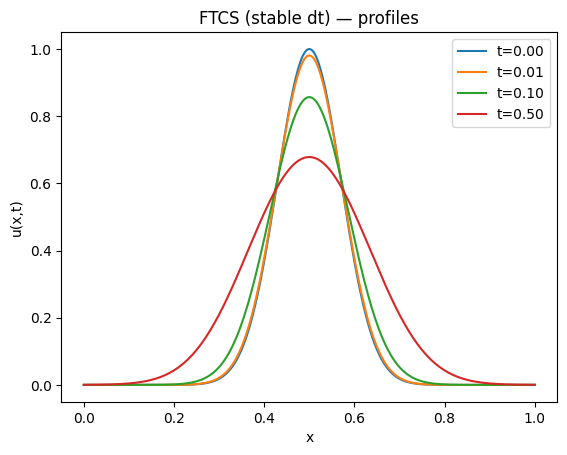

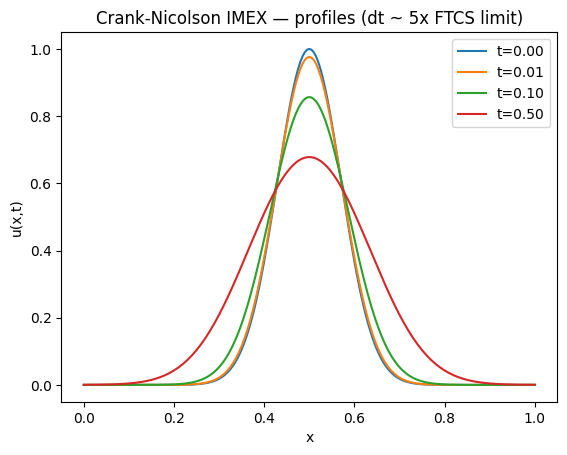

In [11]:
t_targets = [0.0, 0.01, 0.1, 0.5]
t_end = max(t_targets)
dt_lim = dt_limit_diffusion(D, dx)

dt_ftcs = 0.5 * dt_lim
t_ftcs, U_ftcs = solve_ftcs(u_init, dt_ftcs, t_end, clamp01=False, allow_unstable=False)

def nearest_idx(times, t):
    return int(np.argmin(np.abs(times - t)))

plt.figure()
for t in t_targets:
    idx = nearest_idx(t_ftcs, t)
    plt.plot(x, U_ftcs[idx], label=f"t={t:.2f}")
plt.xlabel("x"); plt.ylabel("u(x,t)"); plt.title("FTCS (stable dt) — profiles"); plt.legend()
plt.show()

dt_cn = 5.0 * dt_lim
t_cn, U_cn = solve_cn_imex(u_init, dt_cn, t_end)

plt.figure()
for t in t_targets:
    idx = nearest_idx(t_cn, t)
    plt.plot(x, U_cn[idx], label=f"t={t:.2f}")
plt.xlabel("x"); plt.ylabel("u(x,t)"); plt.title("Crank-Nicolson IMEX — profiles (dt ~ 5x FTCS limit)"); plt.legend()
plt.show()

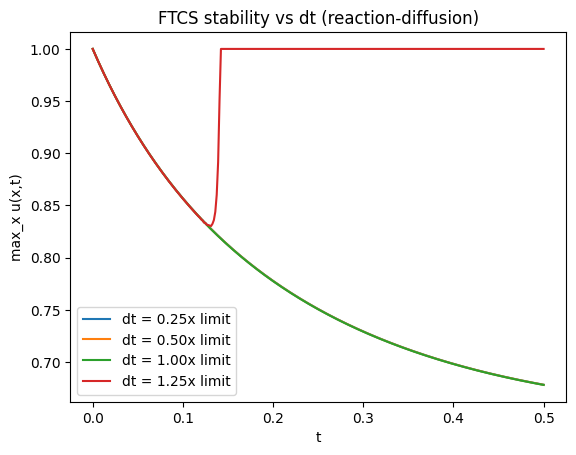

In [12]:
multipliers = [0.25, 0.5, 1.0, 1.25]  
t_end_stab = 0.5
results = {}

with np.errstate(over='ignore', invalid='ignore', divide='ignore'):
    for m in multipliers:
        dt = m * dt_lim
        try:
            t_vec, U = solve_ftcs(u_init, dt, t_end_stab, clamp01=True, allow_unstable=(m>1.0))
            results[m] = (t_vec, U.max(axis=1))
        except (FloatingPointError, ValueError) as e:
            steps = int(np.ceil(t_end_stab/dt))
            t_vec = np.linspace(0.0, t_end_stab, steps+1)
            max_vals = np.full_like(t_vec, np.nan, dtype=float)
            results[m] = (t_vec, max_vals)

plt.figure()
for m in multipliers:
    t_vec, max_vals = results[m]
    plt.plot(t_vec, max_vals, label=f"dt = {m:.2f}x limit")
plt.xlabel("t"); plt.ylabel("max_x u(x,t)"); plt.title("FTCS stability vs dt (reaction-diffusion)"); plt.legend()
plt.show()